# Entrenamiento y Evaluación de Modelos

Entrena y evalúa modelos de clasificación para predecir el comportamiento de precios (Alza/Estable/Caída).

In [73]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report 
)
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [74]:
%run "preprocesamiento.ipynb"

Variable        Type         Data/Info
--------------------------------------
X               DataFrame    Shape: (15985, 9)
X_test          DataFrame    Shape: (2664, 9)
X_train         DataFrame    Shape: (13321, 9)
cm_df           DataFrame    Shape: (3, 3)
df              DataFrame    Shape: (16215, 18)
df_candidatos   DataFrame    Shape: (6, 5)
df_crudo        DataFrame    Shape: (23218, 12)
df_limpio       DataFrame    Shape: (15985, 18)
df_modelo       DataFrame    Shape: (16215, 18)
metrics_df      DataFrame    Shape: (5, 4)
tabla           DataFrame    Shape: (6, 4)
Registros en el dataset final: 16215
comportamiento
Estable    12584
Alza        1913
Caída       1718
Name: count, dtype: int64

comportamiento
Estable    77.6
Alza       11.8
Caída      10.6
Name: proportion, dtype: float64
142
['2020-01-Q1', '2020-01-Q2', '2020-02-Q1', '2020-02-Q2', '2020-03-Q1', '2020-03-Q2', '2020-04-Q1', '2020-04-Q2', '2020-05-Q1', '2020-05-Q2', '2020-06-Q1', '2020-06-Q2', '2020-07-Q1', '2020

## Carga del dataset preprocesado

In [75]:
df_crudo = pd.read_csv('data/processed/dataset_crudo_sipa.csv')
resultado_preproc = preprocesar_datos(df_crudo)
df = resultado_preproc['dataset_final']

print(f"Registros: {len(df)}")
print(df.columns.tolist())

Registros: 16215
['producto', 'provincia', 'periodo', 'precio_actual', 'precio_t1', 'precio_t2', 'variacion_t2_t1', 'promedio_movil_2q', 'promedio_movil_3q', 'año', 'mes', 'quincena', 'variacion_real', 'comportamiento', 'categoria', 'producto_encoded', 'provincia_encoded', 'categoria_perecedero']


In [76]:
for col in df.columns:
    print(col)

producto
provincia
periodo
precio_actual
precio_t1
precio_t2
variacion_t2_t1
promedio_movil_2q
promedio_movil_3q
año
mes
quincena
variacion_real
comportamiento
categoria
producto_encoded
provincia_encoded
categoria_perecedero


## Paso 1 — Limpieza de filas sin historia suficiente (NaN por rezago)

Eliminar filas donde `precio_t2`, `variacion_t2_t1`, `promedio_movil_2q` o `promedio_movil_3q` sean NaN. Estas filas no tienen historia suficiente para generar features de rezago.

In [77]:
features_rezago = ['precio_t2', 'variacion_t2_t1', 'promedio_movil_2q', 'promedio_movil_3q']

print('Filas con NaN en features de rezago:')
for col in features_rezago:
    n_nan = df[col].isna().sum()
    print(f'  {col}: {n_nan} NaN ({n_nan/len(df)*100:.1f}%)')

filas_antes = len(df)
df_limpio = df.dropna(subset=features_rezago).copy()
filas_despues = len(df_limpio)
filas_eliminadas = filas_antes - filas_despues

print(f'\n--- Resumen limpieza ---')
print(f'Filas antes:        {filas_antes}')
print(f'Filas eliminadas:   {filas_eliminadas} ({filas_eliminadas/filas_antes*100:.1f}%)')
print(f'Filas disponibles:  {filas_despues}')
print(f'\nDistribución después de limpieza:')
print(df_limpio['comportamiento'].value_counts())

Filas con NaN en features de rezago:
  precio_t2: 115 NaN (0.7%)
  variacion_t2_t1: 115 NaN (0.7%)
  promedio_movil_2q: 115 NaN (0.7%)
  promedio_movil_3q: 230 NaN (1.4%)

--- Resumen limpieza ---
Filas antes:        16215
Filas eliminadas:   230 (1.4%)
Filas disponibles:  15985

Distribución después de limpieza:
comportamiento
Estable    12357
Alza        1912
Caída       1716
Name: count, dtype: int64


## Paso 2 — Variables predictoras y target

In [78]:
FEATURES = [
    'precio_t1', 'precio_t2', 'variacion_t2_t1',
    'promedio_movil_2q', 'promedio_movil_3q',
    'mes', 'producto_encoded', 'provincia_encoded', 'categoria_perecedero'
]
TARGET = 'comportamiento'

X = df_limpio[FEATURES].copy()
y = df_limpio[TARGET].copy()

# Codificar target a numérico para XGBoost
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
print(f'Mapeo target: {dict(zip(le_target.classes_, range(len(le_target.classes_))))}')
print(f'Features shape: {X.shape}')
print(f'Target shape: {y_encoded.shape}')
print(f'\nNaN restantes en X:')
print(X.isna().sum())

Mapeo target: {'Alza': 0, 'Caída': 1, 'Estable': 2}
Features shape: (15985, 9)
Target shape: (15985,)

NaN restantes en X:
precio_t1               0
precio_t2               0
variacion_t2_t1         0
promedio_movil_2q       0
promedio_movil_3q       0
mes                     0
producto_encoded        0
provincia_encoded       0
categoria_perecedero    0
dtype: int64


## Paso 3 — División temporal (TimeSeriesSplit)

Los datos son series de tiempo: no se puede usar shuffle aleatorio. Se usa `TimeSeriesSplit` con 5 splits.

In [79]:
tscv = TimeSeriesSplit(n_splits=5)

print('Divisiones temporales:')
for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
    print(f'  Fold {i+1}: train={len(train_idx)} filas, test={len(test_idx)} filas')
    print(f'           train periodos: {df_limpio.iloc[train_idx]["periodo"].min()} -> {df_limpio.iloc[train_idx]["periodo"].max()}')
    print(f'           test  periodos: {df_limpio.iloc[test_idx]["periodo"].min()} -> {df_limpio.iloc[test_idx]["periodo"].max()}')

Divisiones temporales:
  Fold 1: train=2665 filas, test=2664 filas
           train periodos: 2020-02-Q2 -> 2025-12-Q2
           test  periodos: 2020-02-Q2 -> 2025-12-Q2
  Fold 2: train=5329 filas, test=2664 filas
           train periodos: 2020-02-Q2 -> 2025-12-Q2
           test  periodos: 2020-02-Q2 -> 2025-12-Q2
  Fold 3: train=7993 filas, test=2664 filas
           train periodos: 2020-02-Q2 -> 2025-12-Q2
           test  periodos: 2020-02-Q2 -> 2025-12-Q2
  Fold 4: train=10657 filas, test=2664 filas
           train periodos: 2020-02-Q2 -> 2025-12-Q2
           test  periodos: 2020-02-Q2 -> 2025-12-Q2
  Fold 5: train=13321 filas, test=2664 filas
           train periodos: 2020-02-Q2 -> 2025-12-Q2
           test  periodos: 2020-02-Q2 -> 2025-12-Q2


In [80]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Usa la misma X, y_encoded que ya tienes definidas (9 features, 15985 filas)
tscv = TimeSeriesSplit(n_splits=5)

# Grid de hiperparámetros a probar (ajusta si quieres más/menos combinaciones)
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_weight': [1, 5, 10],   # controla sobreajuste con pocos datos por hoja
    'subsample': [0.7, 1.0],          # ayuda a que no memorice ruido de OCR
}

# Pesos de clase balanceados (igual que ya venían usando)
pesos_completos = compute_sample_weight('balanced', y_encoded)

xgb_base = XGBClassifier(
    tree_method='hist',
    random_state=42,
    eval_metric='mlogloss',
    n_jobs=-1
)

print("Iniciando GridSearchCV... esto puede tardar varios minutos (72 combinaciones x 5 folds = 360 entrenamientos).")

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=tscv,
    scoring='f1_macro',   # optimiza directamente para el criterio que exige el proyecto
    n_jobs=-1,
    verbose=2,
)

grid_search.fit(X, y_encoded, sample_weight=pesos_completos)

print("\n=== MEJORES HIPERPARÁMETROS ENCONTRADOS ===")
print(grid_search.best_params_)
print(f"\nMejor F1-Score (Macro) promedio en validación: {grid_search.best_score_:.4f}")

# Evaluar el mejor modelo con las métricas completas de siempre (accuracy, precision, recall)
mejor_xgb = grid_search.best_estimator_

fold_metrics = []
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

    pesos_train = compute_sample_weight('balanced', y_train)
    modelo_fold = type(mejor_xgb)(**mejor_xgb.get_params())
    modelo_fold.fit(X_train, y_train, sample_weight=pesos_train)
    y_pred = modelo_fold.predict(X_test)

    from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
    fold_metrics.append({
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_macro': f1_score(y_test, y_pred, average='macro'),
        'precision': precision_score(y_test, y_pred, average='macro'),
        'recall': recall_score(y_test, y_pred, average='macro'),
    })

resumen = pd.DataFrame(fold_metrics).mean()
print("\n=== XGBoost OPTIMIZADO — PROMEDIO 5 FOLDS ===")
print(resumen.round(4))
print(f"\n¿Cumple criterios? F1>=0.75: {resumen['f1_macro']>=0.75} | Acc>=0.80: {resumen['accuracy']>=0.80}")

Iniciando GridSearchCV... esto puede tardar varios minutos (72 combinaciones x 5 folds = 360 entrenamientos).
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

=== MEJORES HIPERPARÁMETROS ENCONTRADOS ===
{'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 1.0}

Mejor F1-Score (Macro) promedio en validación: 0.5061

=== XGBoost OPTIMIZADO — PROMEDIO 5 FOLDS ===
accuracy     0.4230
f1_macro     0.3703
precision    0.4570
recall       0.5082
dtype: float64

¿Cumple criterios? F1>=0.75: False | Acc>=0.80: False


## Paso 4 — Entrenamiento de los 6 modelos

Se entrenan los 6 modelos bajo las mismas condiciones (mismas features, mismo split temporal).

In [81]:
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

MODELOS_QUE_NECESITAN_ESCALADO = {"Logistic Regression", "SVM"}

print("Columnas en X:", X.columns.tolist())
print("Shape de X:", X.shape)
print(X.head(3))

modelos_config = {
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1, class_weight='balanced'),
    'XGBoost': XGBClassifier(learning_rate=0.05, max_depth=10, n_estimators=200, tree_method='hist', random_state=42, eval_metric='mlogloss', n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, min_samples_split=5, random_state=42, class_weight='balanced'),
    'Logistic Regression': LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42, class_weight='balanced'),
    'KNN': KNeighborsClassifier(n_neighbors=5, weights='distance'),
    'SVM': SVC(C=1.0, kernel='rbf', random_state=42, class_weight='balanced', probability=True),
}

resultados = {}

for nombre, modelo_base in modelos_config.items():
    print(f'\n{"="*50}')
    print(f'  {nombre}')
    print(f'{"="*50}')

    fold_metrics = []
    fold_matrices = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

        # --- Escalado solo para modelos sensibles a la magnitud (LR, SVM) ---
        if nombre in MODELOS_QUE_NECESITAN_ESCALADO:
            scaler = StandardScaler()
            X_train_fit = scaler.fit_transform(X_train)
            X_test_fit = scaler.transform(X_test)
        else:
            X_train_fit = X_train
            X_test_fit = X_test

        modelo = type(modelo_base)(**modelo_base.get_params())

        if nombre == 'XGBoost':
            pesos_train = compute_sample_weight('balanced', y_train)
            modelo.fit(X_train_fit, y_train, sample_weight=pesos_train)
        else:
            modelo.fit(X_train_fit, y_train)

        y_pred = modelo.predict(X_test_fit)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro')
        prec = precision_score(y_test, y_pred, average='macro')
        rec = recall_score(y_test, y_pred, average='macro')
        cm = confusion_matrix(y_test, y_pred)

        fold_metrics.append({'accuracy': acc, 'f1_macro': f1, 'precision': prec, 'recall': rec})
        fold_matrices.append(cm)

        print(f'  Fold {fold+1}: acc={acc:.4f} | f1={f1:.4f} | prec={prec:.4f} | rec={rec:.4f}')

    metrics_df = pd.DataFrame(fold_metrics)
    promedios = metrics_df.mean().to_dict()
    cm_ultimo = fold_matrices[-1]

    resultados[nombre] = {
        'metricas': promedios,
        'metricas_por_fold': metrics_df,
        'matriz_confusion': cm_ultimo,
        'modelo_entrenado': modelo,
        'feature_importances': modelo.feature_importances_ if hasattr(modelo, 'feature_importances_') else None,
    }

    print(f'\n  PROMEDIO: acc={promedios["accuracy"]:.4f} | f1={promedios["f1_macro"]:.4f} | prec={promedios["precision"]:.4f} | rec={promedios["recall"]:.4f}')

Columnas en X: ['precio_t1', 'precio_t2', 'variacion_t2_t1', 'promedio_movil_2q', 'promedio_movil_3q', 'mes', 'producto_encoded', 'provincia_encoded', 'categoria_perecedero']
Shape de X: (15985, 9)
   precio_t1  precio_t2  variacion_t2_t1  promedio_movil_2q  \
2      26.25      26.44            -0.72             26.345   
3      26.25      26.25             0.00             26.250   
4      26.25      26.25             0.00             26.250   

   promedio_movil_3q  mes  producto_encoded  provincia_encoded  \
2            26.4400    2                 0                  0   
3            26.3133    3                 0                  0   
4            26.2500    3                 0                  0   

   categoria_perecedero  
2                     0  
3                     0  
4                     0  

  Random Forest
  Fold 1: acc=0.5409 | f1=0.4077 | prec=0.4630 | rec=0.4409
  Fold 2: acc=0.5462 | f1=0.4228 | prec=0.4420 | rec=0.5240
  Fold 3: acc=0.4872 | f1=0.3686 | prec=0.4

## Paso 5 — Evaluación y métricas comparativas

In [82]:
# Tabla comparativa
tabla = pd.DataFrame({
    nombre: res['metricas'] for nombre, res in resultados.items()
}).T
tabla = tabla[['accuracy', 'f1_macro', 'precision', 'recall']]
tabla.columns = ['Accuracy', 'F1-Score (Macro)', 'Precision (Macro)', 'Recall (Macro)']
tabla = tabla.round(4)

print('=== TABLA COMPARATIVA DE MODELOS ===\n')
print(tabla.to_string())
print(f'\nCriterios de selección: F1-Score >= 0.75 AND Accuracy >= 0.80')

for nombre, res in resultados.items():
    cumple_f1 = res['metricas']['f1_macro'] >= 0.75
    cumple_acc = res['metricas']['accuracy'] >= 0.80
    estado = 'CUMPLE' if (cumple_f1 and cumple_acc) else 'NO CUMPLE'
    print(f'  {nombre}: {estado} (F1={res["metricas"]["f1_macro"]:.4f}, Acc={res["metricas"]["accuracy"]:.4f})')

=== TABLA COMPARATIVA DE MODELOS ===

                     Accuracy  F1-Score (Macro)  Precision (Macro)  Recall (Macro)
Random Forest          0.4845            0.3918             0.4434          0.4951
XGBoost                0.5673            0.3818             0.3970          0.4167
Decision Tree          0.4128            0.3556             0.4473          0.4935
Logistic Regression    0.3983            0.3315             0.4379          0.4679
KNN                    0.6447            0.3472             0.3867          0.3608
SVM                    0.3373            0.3036             0.4368          0.4612

Criterios de selección: F1-Score >= 0.75 AND Accuracy >= 0.80
  Random Forest: NO CUMPLE (F1=0.3918, Acc=0.4845)
  XGBoost: NO CUMPLE (F1=0.3818, Acc=0.5673)
  Decision Tree: NO CUMPLE (F1=0.3556, Acc=0.4128)
  Logistic Regression: NO CUMPLE (F1=0.3315, Acc=0.3983)
  KNN: NO CUMPLE (F1=0.3472, Acc=0.6447)
  SVM: NO CUMPLE (F1=0.3036, Acc=0.3373)


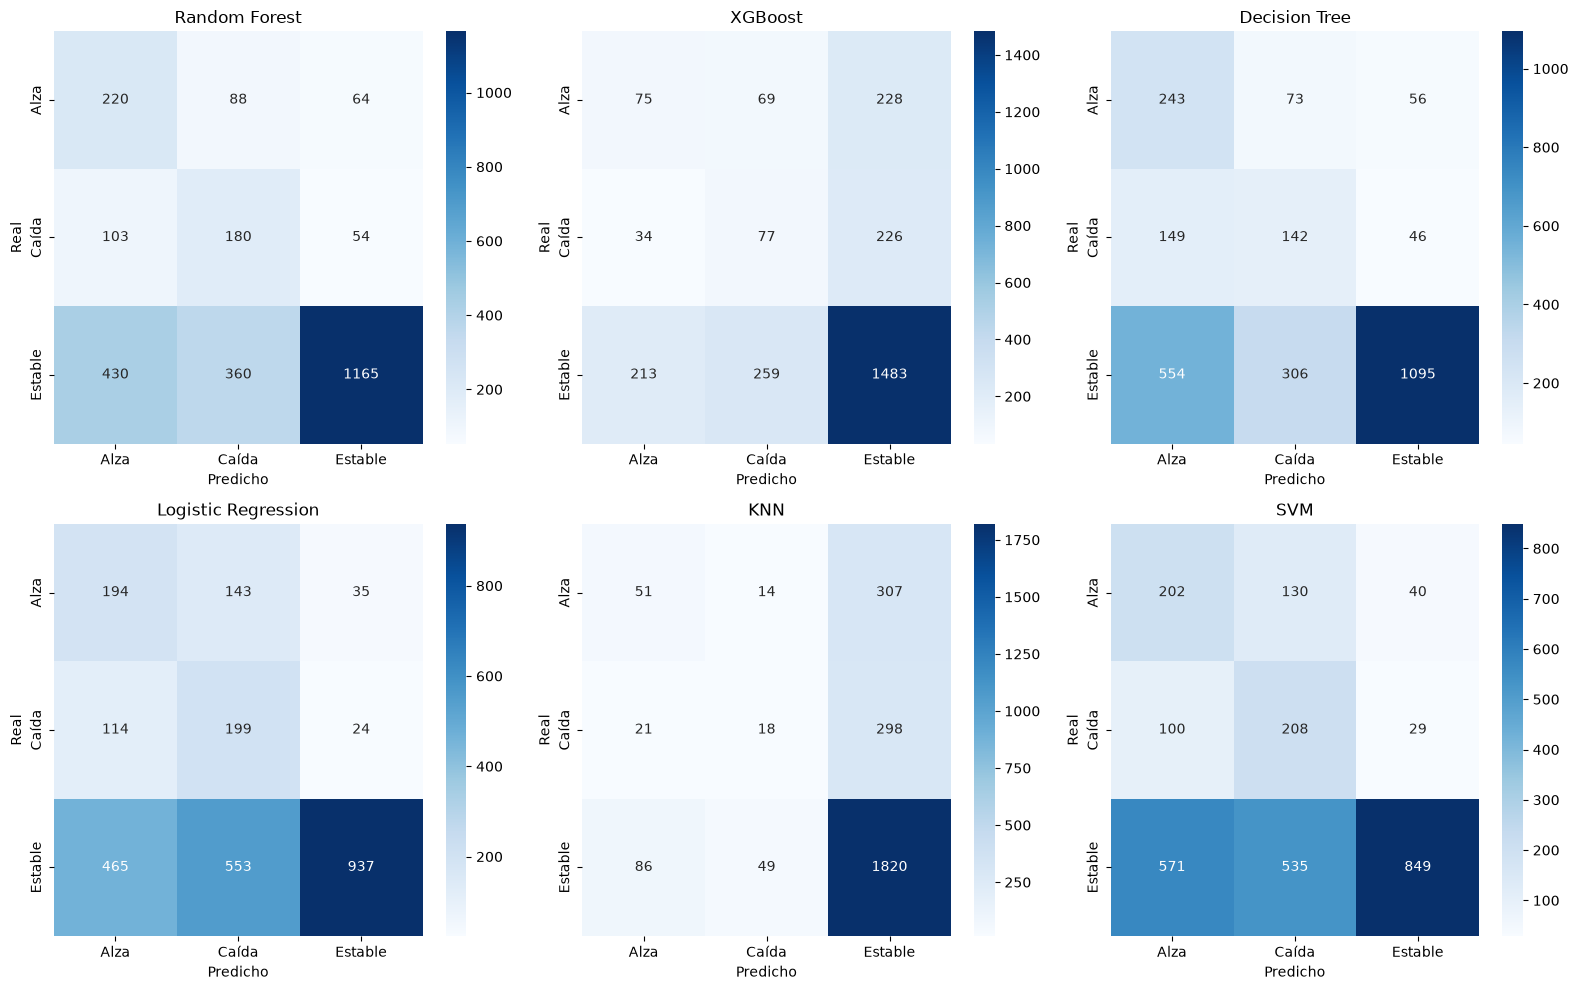

In [83]:
# Matrices de confusión
n_modelos = len(resultados)
n_cols = 3
n_rows = (n_modelos + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten() if n_modelos > 1 else [axes]

for idx, (nombre, res) in enumerate(resultados.items()):
    cm = res['matriz_confusion']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=le_target.classes_, yticklabels=le_target.classes_)
    axes[idx].set_title(f'{nombre}')
    axes[idx].set_xlabel('Predicho')
    axes[idx].set_ylabel('Real')

# Ocultar ejes vacíos
for idx in range(n_modelos, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## Paso 7 — Análisis: Importancia de variables

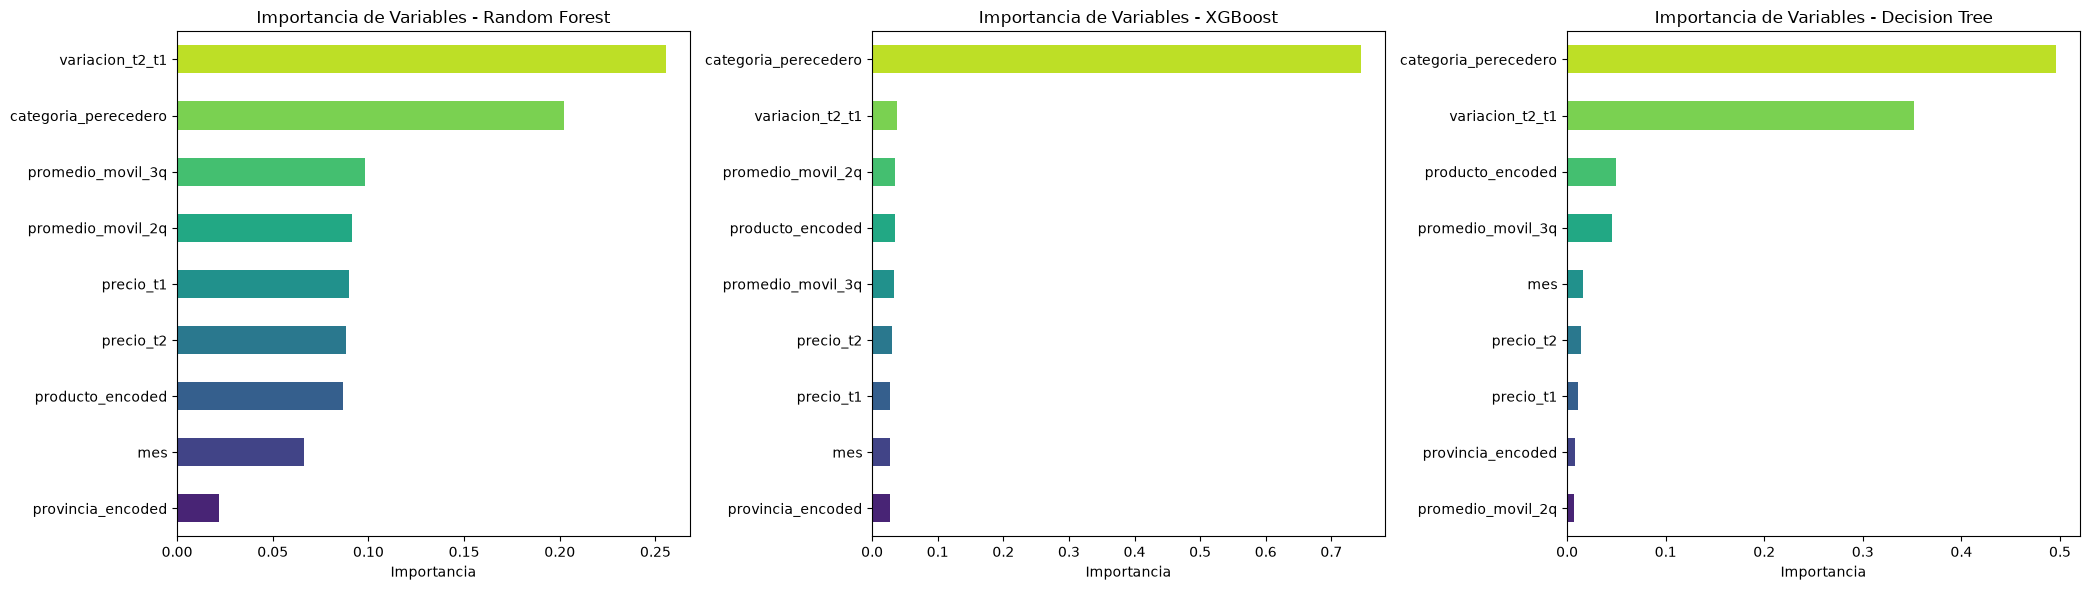

In [84]:
modelos_con_importancia = {k: v for k, v in resultados.items() if v['feature_importances'] is not None}
n_imp = len(modelos_con_importancia)
if n_imp > 0:
    fig, axes = plt.subplots(1, n_imp, figsize=(7 * n_imp, 6))
    axes = axes if n_imp > 1 else [axes]
    for idx, (nombre, res) in enumerate(modelos_con_importancia.items()):
        importancias = pd.Series(res['feature_importances'], index=FEATURES).sort_values(ascending=True)
        importancias.plot(kind='barh', ax=axes[idx], color=sns.color_palette('viridis', len(FEATURES)))
        axes[idx].set_title(f'Importancia de Variables - {nombre}')
        axes[idx].set_xlabel('Importancia')
    plt.tight_layout()
    plt.show()
else:
    print('Ningún modelo tiene feature_importances_ disponible.')

## Selección del modelo final

Criterios: F1-Score (Macro) >= 0.75 AND Accuracy >= 0.80. Si ambos cumplen, se selecciona el que tenga menor cantidad de falsos positivos/negativos.

In [85]:
candidatos = []
for nombre, res in resultados.items():
    f1 = res['metricas']['f1_macro']
    acc = res['metricas']['accuracy']
    cm = res['matriz_confusion']
    falsos = cm.sum() - np.trace(cm)  # falsos positivos + falsos negativos
    cumple = f1 >= 0.75 and acc >= 0.80
    candidatos.append({
        'Modelo': nombre,
        'F1-Score': f1,
        'Accuracy': acc,
        'Falsos (total)': falsos,
        'Cumple criterios': 'SI' if cumple else 'NO'
    })

df_candidatos = pd.DataFrame(candidatos)
print('=== MODELOS CANDIDATOS ===\n')
print(df_candidatos.to_string(index=False))

# Seleccionar mejor modelo
candidatos_validos = [c for c in candidatos if c['Cumple criterios'] == 'SI']
if candidatos_validos:
    mejor = min(candidatos_validos, key=lambda x: x['Falsos (total)'])
    print(f'\n>> MODELO SELECCIONADO: {mejor["Modelo"]}')
    print(f'   F1-Score: {mejor["F1-Score"]:.4f} | Accuracy: {mejor["Accuracy"]:.4f} | Falsos: {mejor["Falsos (total)"]}')
else:
    # Si ninguno cumple, seleccionar el de mayor F1
    mejor = max(candidatos, key=lambda x: x['F1-Score'])
    print(f'\n>> NINGUNO CUMPLE LOS CRITERIOS. Mejor por F1-Score: {mejor["Modelo"]}')
    print(f'   F1-Score: {mejor["F1-Score"]:.4f} | Accuracy: {mejor["Accuracy"]:.4f}')

=== MODELOS CANDIDATOS ===

             Modelo  F1-Score  Accuracy  Falsos (total) Cumple criterios
      Random Forest  0.391844  0.484459            1099               NO
            XGBoost  0.381835  0.567267            1029               NO
      Decision Tree  0.355560  0.412763            1184               NO
Logistic Regression  0.331459  0.398348            1334               NO
                KNN  0.347184  0.644670             775               NO
                SVM  0.303560  0.337312            1405               NO

>> NINGUNO CUMPLE LOS CRITERIOS. Mejor por F1-Score: Random Forest
   F1-Score: 0.3918 | Accuracy: 0.4845


## Análisis cualitativo

In [86]:
# Análisis de la matriz de confusión del mejor modelo
mejor_nombre = mejor['Modelo']
cm_mejor = resultados[mejor_nombre]['matriz_confusion']
clases = le_target.classes_

print(f'=== ANÁLISIS DE MATRIZ DE CONFUSIÓN - {mejor_nombre} ===\n')
print('Matriz de confusión (último fold):\n')
cm_df = pd.DataFrame(cm_mejor, index=[f'Real: {c}' for c in clases], columns=[f'Pred: {c}' for c in clases])
print(cm_df.to_string())

# Diagonal = correctos
correctos = np.trace(cm_mejor)
total = cm_mejor.sum()
print(f'\nCorrectos: {correctos}/{total} ({correctos/total*100:.1f}%)')

# Errores más comunes
print('\nErrores más comunes:')
for i, real in enumerate(clases):
    for j, pred in enumerate(clases):
        if i != j and cm_mejor[i][j] > 0:
            print(f'  Real={real} -> Pred={pred}: {cm_mejor[i][j]} veces')

=== ANÁLISIS DE MATRIZ DE CONFUSIÓN - Random Forest ===

Matriz de confusión (último fold):

               Pred: Alza  Pred: Caída  Pred: Estable
Real: Alza            220           88             64
Real: Caída           103          180             54
Real: Estable         430          360           1165

Correctos: 1565/2664 (58.7%)

Errores más comunes:
  Real=Alza -> Pred=Caída: 88 veces
  Real=Alza -> Pred=Estable: 64 veces
  Real=Caída -> Pred=Alza: 103 veces
  Real=Caída -> Pred=Estable: 54 veces
  Real=Estable -> Pred=Alza: 430 veces
  Real=Estable -> Pred=Caída: 360 veces


## Guardado del modelo y artefactos

In [87]:
os.makedirs('data/models', exist_ok=True)

# Mejor modelo entrenado
modelo_final = resultados[mejor['Modelo']]['modelo_entrenado']
joblib.dump(modelo_final, 'data/models/mejor_modelo.pkl')

# Encoders
joblib.dump(le_target, 'data/models/le_target.pkl')
joblib.dump(le_producto, 'data/models/le_producto.pkl')
joblib.dump(le_provincia, 'data/models/le_provincia.pkl')

# Lista de features (referencia)
joblib.dump(FEATURES, 'data/models/features.pkl')

print('Artefactos guardados en data/models/:')
for f in sorted(os.listdir('data/models/')):
    size = os.path.getsize(f'data/models/{f}')
    print(f'  {f} ({size:,} bytes)')

print(f'\nModelo: {mejor["Modelo"]}')
print(f'F1-Score: {mejor["F1-Score"]:.4f} | Accuracy: {mejor["Accuracy"]:.4f}')

NameError: name 'le_producto' is not defined